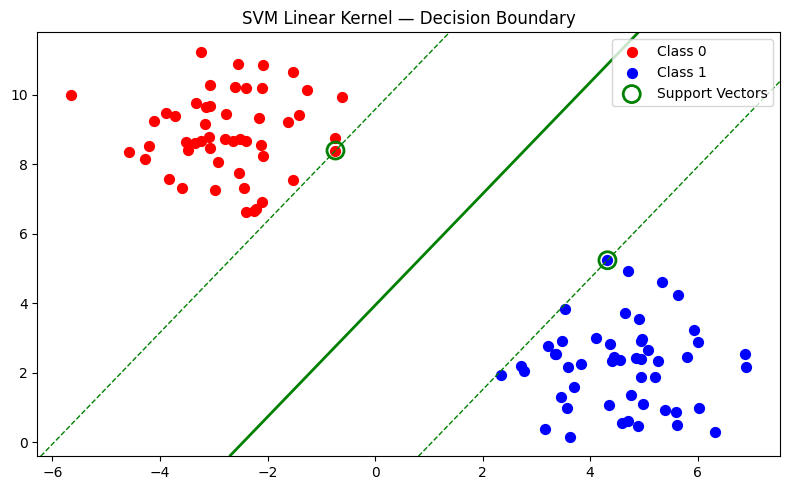

Support vectors: 2


In [ ]:
## Day 14 — SVM (Support Vector Machines)
### Key Learnings:
- SVM finds the maximum margin boundary between classes
- Support vectors are the only points that define the boundary
- Linear kernel: works when data is linearly separable
- RBF kernel: works when data needs curved boundaries (kernel trick)
- High C = fewer support vectors = risk of overfitting
- Low C = more support vectors = smoother boundary
- SVM MUST have scaled features — always use StandardScaler
- GridSearchCV automates finding best hyperparameters
- All classical models performed within 1% on Titanic = ceiling effect


import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report
import pandas as pd

# Create simple 2D data to visualize
from sklearn.datasets import make_blobs

X_vis, y_vis = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)

# Train SVM
svm_vis = SVC(kernel='linear', C=1)
svm_vis.fit(X_vis, y_vis)

# Plot the decision boundary
def plot_svm(model, X, y, title):
    plt.figure(figsize=(8, 5))

    # plot points
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='red', label='Class 0', s=50)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='blue', label='Class 1', s=50)

    # plot decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # decision boundary and margins
    ax.contour(XX, YY, Z, colors='green', levels=[-1, 0, 1],
               linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

    # support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=150, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=100)
    plt.show()
    print(f"Support vectors: {len(model.support_vectors_)}")

plot_svm(svm_vis, X_vis, y_vis, "SVM Linear Kernel — Decision Boundary")

In [ ]:
# Data that is NOT linearly separable (circles inside circles)
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

plt.figure(figsize=(12, 4))

# Try linear kernel — will fail
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_circ, y_circ)
score_linear = svm_linear.score(X_circ, y_circ)

# Try RBF kernel — will work
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_circ, y_circ)
score_rbf = svm_rbf.score(X_circ, y_circ)

print(f"Linear kernel on circular data: {score_linear:.4f}")
print(f"RBF kernel on circular data:    {score_rbf:.4f}")
print(f"\nRBF wins by: {score_rbf - score_linear:.4f}")

Linear kernel on circular data: 0.6000
RBF kernel on circular data:    1.0000

RBF wins by: 0.4000


<Figure size 1200x400 with 0 Axes>

In [ ]:
# See how C changes the boundary
C_values = [0.01, 0.1, 1, 10, 100]

print("Effect of C parameter:")
print(f"{'C value':<12} {'Train Acc':<12} {'Test Acc':<12} {'Support Vectors'}")
print("-" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for c in C_values:
    svm = SVC(kernel='linear', C=c)
    svm.fit(X_train_s, y_train)
    train_acc = svm.score(X_train_s, y_train)
    test_acc = svm.score(X_test_s, y_test)
    sv_count = len(svm.support_vectors_)
    print(f"{c:<12} {train_acc:<12.4f} {test_acc:<12.4f} {sv_count}")

Effect of C parameter:
C value      Train Acc    Test Acc     Support Vectors
--------------------------------------------------
0.01         1.0000       1.0000       56
0.1          1.0000       1.0000       12
1            1.0000       1.0000       3
10           1.0000       1.0000       3
100          1.0000       1.0000       3


In [ ]:
# Load and prepare Titanic (same as Day 12-13)
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['HasCabin'] = df['Cabin'].notnull().astype(int)
df['Embarked'] = df['Embarked'].fillna('S')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ['Age', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Pclass']
categorical_features = ['Sex', 'Embarked', 'Title']

X = df[numeric_features + categorical_features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())   # ⚠️ SVM NEEDS scaling — very important!
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Build SVM pipeline
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', C=1, gamma='scale', probability=True))
])

svm_pipeline.fit(X_train, y_train)

print(f"SVM Train: {svm_pipeline.score(X_train, y_train):.4f}")
print(f"SVM Test:  {svm_pipeline.score(X_test, y_test):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, svm_pipeline.predict(X_test)))

SVM Train: 0.8455
SVM Test:  0.8156

Detailed Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1, gamma='scale'),
    'SVM (Linear)':        SVC(kernel='linear', C=1),
}

print(f"{'Model':<25} {'CV Accuracy (5-fold)'}")
print("-" * 45)

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

Model                     CV Accuracy (5-fold)
---------------------------------------------
Logistic Regression       0.8238 ± 0.0204
Random Forest             0.8260 ± 0.0151
SVM (RBF)                 0.8305 ± 0.0260
SVM (Linear)              0.8328 ± 0.0219


In [ ]:
# GridSearchCV tries every combination and finds the best
param_grid = {
    'model__C':      [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma':  ['scale', 'auto']
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score:   {grid_search.best_score_:.4f}")
print(f"Test score:      {grid_search.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters: {'model__C': 1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV score:   0.8356
Test score:      0.8156
